# Regime Detection Notebook

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from regime_detection.data.ingestion import get_merged_df
from regime_detection.features.features import feature_pipeline
from regime_detection.models.stationarity import stationarity_pipeline


## Config

In [3]:
seed = 42

In [4]:
df_raw = get_merged_df()

df_features = feature_pipeline(df_raw)

split_ratio = .8
split_index = int(len(df_features) * split_ratio)

df_train , df_test = df_features.iloc[:split_index, :], df_features.iloc[split_index:, :]

df_test.head()

Computing log returns...
Computing week-on-week changes...
Computing lagged values...
Computing rolling returns volatility...
Computing commodity-to-commodity differences...
Computing rolling window z-scores...


,RBRTE,RWTC,T10Y2Y,VIXCLS,DTWEXBGS,WCESTUS1,RNGWHHD,days_since_opec,days_since_fomc,RBRTE_log_return,...,RBRTE_log_return_12_returns_rol_vol,RWTC_log_return_4_returns_rol_vol,RWTC_log_return_12_returns_rol_vol,RNGWHHD_log_return_4_returns_rol_vol,RNGWHHD_log_return_12_returns_rol_vol,RBRTE_RWTC_diff,RBRTE_log_return_rol_z_score,RWTC_log_return_rol_z_score,RNGWHHD_log_return_rol_z_score,RBRTE_RWTC_diff_rol_z_score
period,,,,,,,,,,,,,,,,,,,,,
2022-07-22,113.53,102.24,-0.21,23.03,122.4510,422086,7.76,23.0,37,0.033407,...,0.045573,0.047635,0.045172,0.106881,0.116729,11.29,0.537880,0.322649,1.314236,2.594249
2022-07-29,109.28,99.60,-0.22,21.33,121.7678,426553,8.74,30.0,2,-0.038154,...,0.044035,0.038746,0.044103,0.102602,0.111721,9.68,-0.953344,-0.670372,1.078905,1.918321
2022-08-05,102.54,94.01,-0.41,21.15,122.3210,432010,8.14,37.0,9,-0.063660,...,0.047180,0.033852,0.046566,0.101415,0.111565,8.53,-1.450389,-1.284388,-0.922796,1.461844
2022-08-12,104.64,94.65,-0.41,19.53,121.0180,424954,8.15,44.0,16,0.020273,...,0.044823,0.035868,0.040604,0.099154,0.108126,9.99,0.282041,0.023362,-0.162584,1.872868
2022-08-19,96.73,91.81,-0.27,20.60,123.0501,421672,9.19,51.0,23,-0.078602,...,0.046595,0.026459,0.040052,0.093942,0.112090,4.92,-1.685896,-0.706424,1.073761,0.159575


In [5]:
df_train = stationarity_pipeline(df_train)

RBRTE_log_return was transformed using none and it's stationarity class is now stationary
RWTC_log_return was transformed using none and it's stationarity class is now stationary
RNGWHHD_log_return was transformed using none and it's stationarity class is now stationary
WCESTUS1_1_w_change was transformed using none and it's stationarity class is now stationary
T10Y2Y was transformed using differenced and it's stationarity class is now stationary
VIXCLS was transformed using differenced and it's stationarity class is now stationary
DTWEXBGS was transformed using differenced and it's stationarity class is now stationary


In [ ]:
df_model = df_train.dropna()

#X = df_model[['WCESTUS1_1_w_change_stationary', 'days_since_opec', 'days_since_fomc']]

X = df_model[[
    'WCESTUS1_1_w_change_stationary',  # inventory surprise
    'RBRTE_RWTC_diff',                  # brent-wti spread
    'VIXCLS',                           # risk sentiment
    'T10Y2Y_stationary',                # yield curve
    'DTWEXBGS_stationary',              # dollar index
]]

X = sm.add_constant(X)


wti_y = df_model['RWTC_log_return_stationary'].values.reshape(-1,1)


brent_y = df_model['RBRTE_log_return_stationary'].values.reshape(-1,1)

henry_y = df_model['RNGWHHD_log_return_stationary'].values.reshape(-1,1)

wti_model = sm.OLS(wti_y,X)
brent_model = sm.OLS(brent_y,X)
henry_model = sm.OLS(henry_y, X)


wti_results = wti_model.fit()
brent_results = brent_model.fit()
henry_results = henry_model.fit()

wti_resid= wti_results.resid
brent_resid = brent_results.resid
henry_resid = henry_results.resid


### Evaluating Autocorrelation with the Ljung-Box Test

In [6]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_wti = acorr_ljungbox(wti_resid, lags =[4,12], return_df = True)
lb_brent = acorr_ljungbox(brent_resid, lags=[4,12], return_df = True)
lb_henry = acorr_ljungbox(henry_resid, lags= [4,12], return_df = True)

print(f"WTI {lb_wti}")
print(f"Brent{lb_brent}")
print(f"Henry {lb_henry}")

NameError: name 'wti_resid' is not defined

The Ljung-Box test's null hypothesis is that residuals are not autocorrelated within a window of the last n observations. In this case, we used the Ljung-Box test on WTI, Brent, and Henry Hub, using lags of 4 and 12 weeks. The test shows pvalues well past the threshold of statistical significance, giving us a strong indication of autocorrelation in the residuals.

With this in mind, we're going to use the Newey-West (HAC) estimator in order to evaluate the autocorrelation within our residuals.

## Regression T-Statistics with HAX Standard Errors

In [ ]:
# Evaluating OLS results using HAC for standard errors.
wti_hac_results = wti_model.fit(cov_type="HAC", cov_kwds={'maxlags': 4})
brent_hac_results = brent_model.fit(cov_type="HAC", cov_kwds={'maxlags': 4})
henry_hac_results = henry_model.fit(cov_type="HAC", cov_kwds={'maxlags': 4})

# T-Statistics for the regressors - both using and not using HAC for std errors.
print(f"Henry Hub T-Stat w/o HAC:\n{henry_results.tvalues}\n")
print(f"Henry Hub T-Stat w HAC: \n {henry_hac_results.tvalues}\n")

print(f"Brent T-Stat w/o HAC: \n {brent_results.tvalues}\n")
print(f"Brent T-Stat w HAC: \n {brent_hac_results.tvalues}\n")

print(f"WTI T-Stat w/o HAC: \n {wti_results.tvalues}\n")
print(f"WTI T-Stat w HAC: \n {wti_hac_results.tvalues}\n")

print(f"Henry T-Stat Delta: \n {henry_results.tvalues - henry_hac_results.tvalues}\n")
print(f"Brent T-Stat Delta: \n {brent_results.tvalues - brent_hac_results.tvalues}\n")
print(f"WTI T-Stat Delta: \n {wti_results.tvalues - wti_hac_results.tvalues}\n")





Henry Hub T-Stat w/o HAC:
const                             1.141744
WCESTUS1_1_w_change_stationary   -3.014171
RBRTE_RWTC_diff                  -0.123238
VIXCLS                           -1.262182
T10Y2Y_stationary                 1.852182
DTWEXBGS_stationary              -1.630620
dtype: float64

Henry Hub T-Stat w HAC: 
 const                             1.946096
WCESTUS1_1_w_change_stationary   -1.182553
RBRTE_RWTC_diff                  -0.202945
VIXCLS                           -2.222677
T10Y2Y_stationary                 2.109614
DTWEXBGS_stationary              -1.794092
dtype: float64

Brent T-Stat w/o HAC: 
 const                             4.348553
WCESTUS1_1_w_change_stationary   -1.232470
RBRTE_RWTC_diff                  -0.287739
VIXCLS                           -4.761228
T10Y2Y_stationary                 3.070596
DTWEXBGS_stationary              -8.962849
dtype: float64

Brent T-Stat w HAC: 
 const                             2.677218
WCESTUS1_1_w_change_stationary   -1.2

In [63]:
# We look to comparee which coefficients were statistically significant (ss) before and after using Newey-West for Standard Errors.
print(f"WTI w/o HAC SS Coefs: \n {[tval for tval in wti_results.model.exog_names if abs(wti_results.tvalues[tval]) > np.float64(1.96)]}\n")
print(f"WTI w HAC SS Coefs: \n {[tval for tval in wti_results.model.exog_names if abs(wti_hac_results.tvalues[tval]) > np.float64(1.96)]}\n")

print(f"Henry Hub w/o HAC SS Coefs:\n  {[tval for tval in henry_results.model.exog_names if abs(henry_results.tvalues[tval]) > np.float64(1.96)]}\n")
print(f"Henry Hub w HAC SS Coefs: \n {[tval for tval in henry_results.model.exog_names if abs(henry_hac_results.tvalues[tval]) > np.float64(1.96)]}\n")

print(f"Brent w/o HAC SS Coefs:\n  {[tval for tval in brent_results.model.exog_names if abs(brent_results.tvalues[tval]) > np.float64(1.96)]}\n")
print(f"Brent w HAC SS Coefs: \n{[tval for tval in brent_results.model.exog_names if abs(brent_hac_results.tvalues[tval]) > np.float64(1.96)]}\n")


WTI w/o HAC SS Coefs: 
 ['const', 'VIXCLS', 'T10Y2Y_stationary', 'DTWEXBGS_stationary']

WTI w HAC SS Coefs: 
 ['const', 'T10Y2Y_stationary', 'DTWEXBGS_stationary']

Henry Hub w/o HAC SS Coefs:
  ['WCESTUS1_1_w_change_stationary']

Henry Hub w HAC SS Coefs: 
 ['VIXCLS', 'T10Y2Y_stationary']

Brent w/o HAC SS Coefs:
  ['const', 'VIXCLS', 'T10Y2Y_stationary', 'DTWEXBGS_stationary']

Brent w HAC SS Coefs: 
['const', 'VIXCLS', 'T10Y2Y_stationary', 'DTWEXBGS_stationary']



Newey-West (Heteroskedasticity and Autocorrelation Consistent), is an estimator that estimates the covariance matrix for OLS when it's assumptions are not valid (The time-series exhibits non-constant variance, and/or autocorrelation). If regressor exhibits positive autocorrelation, then regular OLS would underestimate it's variance / std. error, and thus, it's std. error will be larger using HAC, and it there is negative autocorrelation, the opposite will hold. 

The maxlags parameter determines the sixe of the window that it can use to evaluate autocorrelation. When we apply this to WTI, Brent, and Henry Hub, we use maxlags = 4, since that allows the estimator to evaluate autocorrelation in the month before each observation.

Applied to the three models: WTI lost significance in VIXCLS (signalling positive autocorrelation). Brent showed no change. Henry Hub showed both directions at once: the inventory variable (WCESTUS1) lost significance (positive autocorrelation, same pattern as WTI's VIXCLS), while VIXCLS and T10Y2Y_stationary gained significance (negative autocorrelation), confirming that autocorrelation sign is specific to each regressor's residual contribution within a model, not a single property of the model as a whole.

Next, we want to confirm the assumptions we made about the direction of the autocorrelation in our residuals. In order to do this, we will use the Durbin-Watson statistic, which ranges from 0 to 4, where 2 shows no autocorrelation, values below 2 indicate positive autocorrelation, and values larger than 2 show negative autocorrelation.

## Durbin-Watson Statistic

In [67]:
from statsmodels.stats.stattools import durbin_watson

wti_dw_stat = durbin_watson(wti_resid)
henry_dw_stat = durbin_watson(henry_resid)
brent_dw_stat = durbin_watson(brent_resid)

print(f"Durbin-Watson statistic for WTI: {wti_dw_stat:.3}")
print(f"Durbin-Watson statistic for Henry Hub: {henry_dw_stat:.3}")
print(f"Durbin-Watson statistic for Brent: {brent_dw_stat:.3}")

Durbin-Watson statistic for WTI: 2.45
Durbin-Watson statistic for Henry Hub: 2.31
Durbin-Watson statistic for Brent: 1.64


The Durbin-Watson test shows us that there is positive autocorrelation for Brent, whilst there is negative autocorrelation for WTI and Henry Hub. 

# NEED TO FINISH

## ACF / PACF Plots

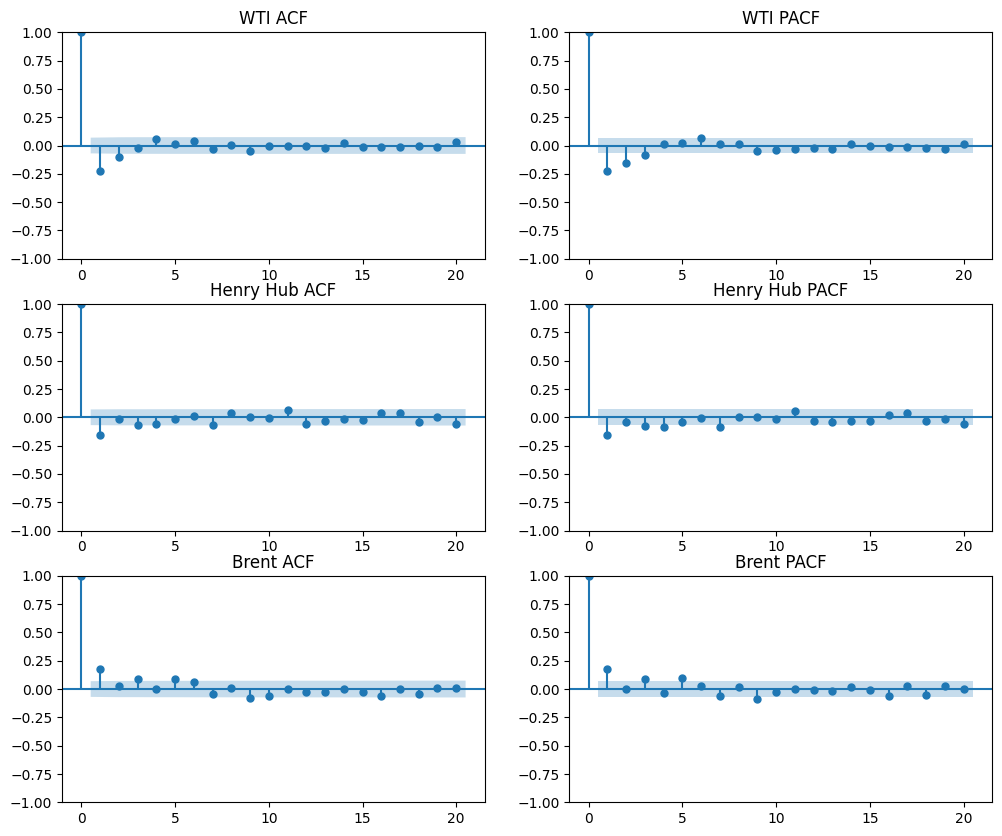

In [79]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3,2, figsize=(12, 10))

plot_acf(wti_resid, ax = axes[0][0], title = "WTI ACF", lags = 20)
plot_pacf(wti_resid, ax = axes[0][1], title = "WTI PACF", lags = 20)

plot_acf(henry_resid, ax = axes[1][0], title = "Henry Hub ACF", lags = 20)
plot_pacf(henry_resid, ax = axes[1][1], title = "Henry Hub PACF", lags = 20)

plot_acf(brent_resid, ax = axes[2][0], title = "Brent ACF", lags = 20)
plot_pacf(brent_resid, ax = axes[2][1], title = "Brent PACF", lags = 20)

plt.show()


# WRTIEUP NEEDED

## R^2 statistic

In [55]:
print(f"Henry Hub R²: {henry_results.rsquared:.4f}")
print(f"Brent R²: {brent_results.rsquared:.4f}")
print(f"WTI R²: {wti_results.rsquared:.4f}\n")

Henry Hub R²: 0.0238
Brent R²: 0.1522
WTI R²: 0.0675



In [ ]:


print(f"WTI Residuals mean: {wti_resid.mean():.6f}, std: {wti_resid.std():.4f}")
print(f"Brent Residuals mean: {brent_resid.mean():.6f}, std: {brent_resid.std():.4f}")
print(f"Henry Hub Residuals mean: {henry_resid.mean():.6f}, std: {henry_resid.std():.4f}")

WTI Residuals mean: -0.000000, std: 0.0945
Brent Residuals mean: -0.000000, std: 0.0462
Henry Hub Residuals mean: -0.000000, std: 0.0958


Observation: The residuals are centered at zero, so we note that there is no bias when it comes to our predictions.

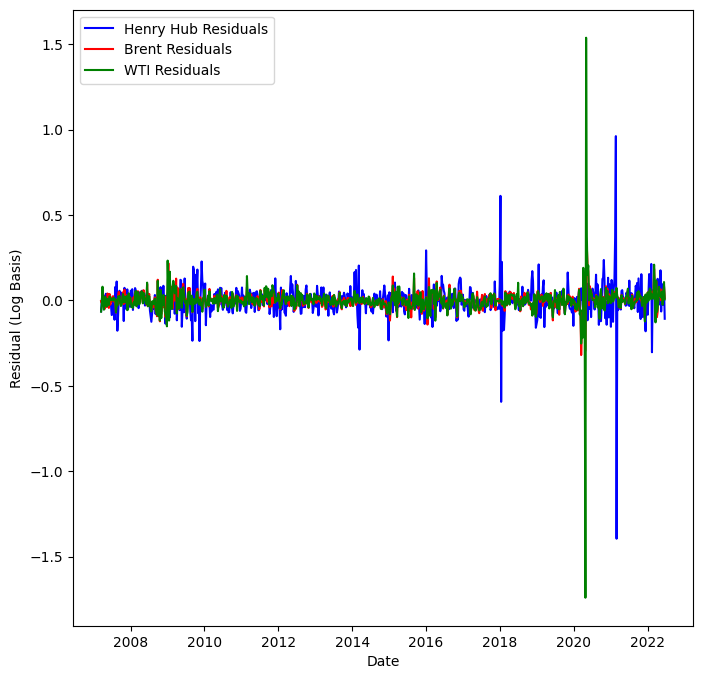

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(henry_resid, "b", label = 'Henry Hub Residuals')
plt.plot(brent_resid, "r", label = 'Brent Residuals')
plt.plot(wti_resid, "g", label = "WTI Residuals")

plt.xlabel(xlabel= "Date")
plt.ylabel(ylabel = "Residual (Log Basis)")
plt.legend(loc="upper left")

In [41]:
from statsmodels.regression.rolling import RollingOLS

results = {}
windows = [52, 78, 104] # weeks


for series, y in [('wti', df_model['RWTC_log_return_stationary']), 
                    ('brent', df_model['RBRTE_log_return_stationary']), 
                    ('henry', df_model['RNGWHHD_log_return_stationary'])]:
    results[series] = {}
    for window in windows:
        model = RollingOLS(y, X, window = window)
        fit = model.fit(cov_type = 'HAC', cov_kwds = {'maxlags': 4})
        results[series][window] = fit


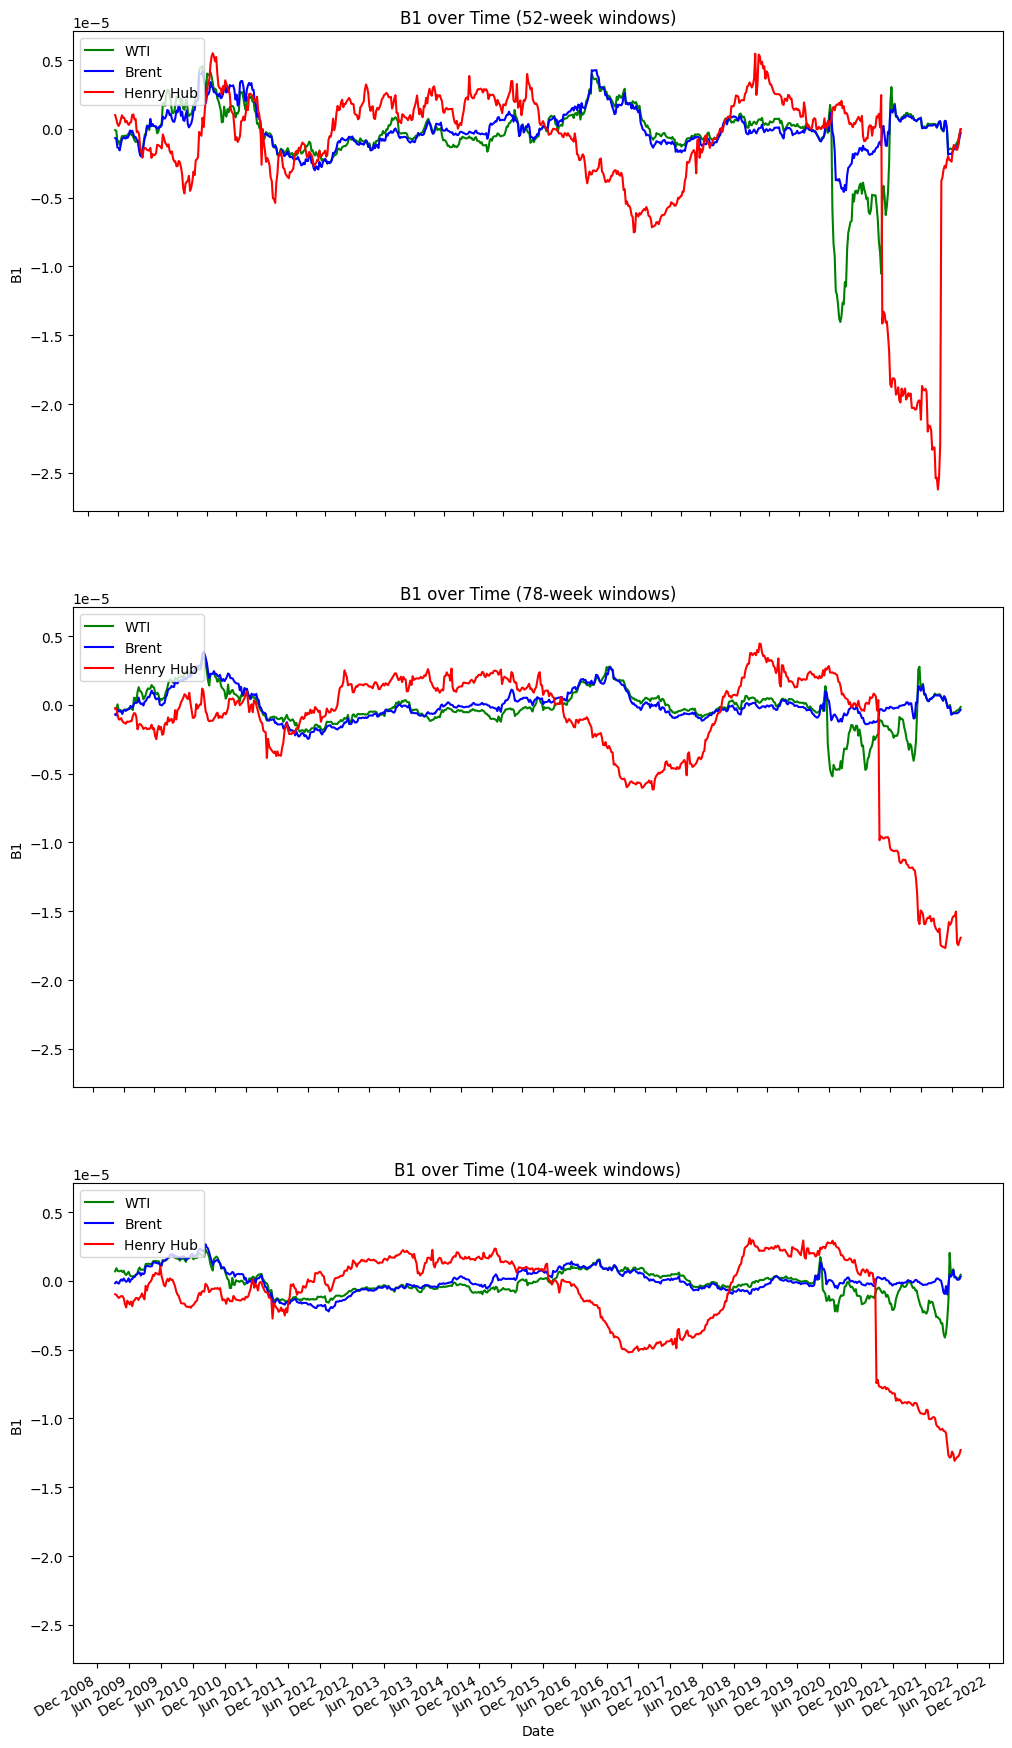

In [52]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(3,1, figsize = (12, 24), sharey= True)
for num, window in enumerate(windows):
    ax = axes[num]
    ax.plot(results['wti'][window].params.iloc[window:, 1], "g",label = 'WTI')
    ax.plot(results['brent'][window].params.iloc[window:, 1], "b",label = 'Brent')
    ax.plot(results['henry'][window].params.iloc[window:, 1], "r",label = 'Henry Hub')

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    ax.set_xlabel(xlabel= "Date")
    ax.set_ylabel(ylabel = "B1")
    ax.set_title( label = f"B1 over Time ({window}-week windows)")
    ax.legend(loc="upper left")

fig.autofmt_xdate() 


As expected, we observe that volatility is inversely proportional to window size. Despite this, we see large crashes for Henry Hub through the three plots, indicating that this crash is representative of a real macro event, rather than just a mistake in our model. Upon researching the behaviour of natural gas from early 2021 until mid 2022, we note that this aligns with the aftermath of the COVID-19 pandemic, where the 

. We note that Brent and WTI stay relatively stable throughout the time frame of our data. 

In [ ]:
from statsmodels.regression.rolling import RollingOLS

results = {}

windows = [72, 104]

for series, y in [('wti', df_model['RWTC_log_return_stationary']), 
                  ('brent', df_model['RBRTE_log_return_stationary']), 
                  ('henry', df_model['RNGWHHD_log_return_stationary'])]:
    for window in windows:
        model = RollingOLS(y, X, window = window)
        fit = model.fit(cov_type = 'HAC', cov_kwds = {'maxlags': 4})
        results[series] = fit